In [ ]:
!pip install qiskit-ibm-runtime
!pip install 'qiskit[visualization]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfully uninstalled requests-2.32.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

import numpy as np
from qiskit.quantum_info import Statevector

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
!pip install qiskit-aer
from qiskit_aer import AerSimulator
backend = AerSimulator()

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.2 MB/s eta 0:00:00


In [ ]:
#initialize groups for graph
optimized_x = []
optimal_fun = []
num_func_evals = []
max_constraint_violation = []
success_flag =[]
message = []

ideal_gs_energy = []
ideal_z_mag = []

error_mag_z = []
system_magnetization_z = []
system_magnetization_x = []
q0_z_mag = []
q1_z_mag = []
q0_x_mag = []
q1_x_mag = []
sys_mag_z = [] # Initialized sys_mag_z here

In [ ]:
h_val = [-2,-1.5,-1, -0.5, 0, 0.5, 1, 1.5,2]
h_values = np.arange(-2,2.22,0.22)
#h_values = [0]

In [ ]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    qc = ansatz.assign_parameters(params)
    psi = Statevector.from_instruction(qc)

    # Fidelity = |<exact|ansatz>|^2
    fidelity = np.abs(np.vdot(exact_gs.data, psi.data))**2

    cost = 1 - fidelity

    # Optional: Track fidelity progress
    print(f"Fidelity: {fidelity}, Cost: {cost}")

    return cost
    # pub = (ansatz, [hamiltonian], [params])
    # result = estimator.run(pubs=[pub]).result()
    # energy = result[0].data.evs[0]

    # cost_history_dict["iters"] += 1
    # cost_history_dict["prev_vector"] = params
    # cost_history_dict["cost_history"].append(energy)
    # print(
    #     f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]"
    # )

    # return energy

In [ ]:
for h in h_values:
  J=1
  hamiltonian = SparsePauliOp.from_list(
    [ ("ZZII", -J), ("IZZI", -J), ("IIZZ",-J), ("XIII", h), ("IXII", h), ("IIXI",h), ("IIIX",h)])
  # Eigenvalues and Eigenvectors calculation using exact diagonalization using numpy eigensolvers.

  hamil=sum(hamiltonian)
  # Find the eigenvalues and eigenvectors of the Hamiltonian
  eigenvalues, eigenvectors = np.linalg.eigh(hamil.to_matrix())

  # Print the eigenvalues
  print("Eigenvalues:")
  for eigenvalue in eigenvalues:
      print(eigenvalue)

  # Print the eigenstates (eigenvectors as Statevector objects)
  print("\nEigenstates:")
  for eigenvector in eigenvectors:
      print(Statevector(eigenvector))


  # Find the index of the smallest eigenvalue (ground state)
  ground_state_index = np.argmin(eigenvalues)

  # Get the ground state eigenvector as a Statevector
  ground_state_vector_1 = Statevector(eigenvectors[0])
  exact_gs = Statevector(eigenvectors[0])
  #exact_gs
  # Define the Z_1 and Z_2 operators (SparsePauliOp objects)
  z1_op = SparsePauliOp.from_list([("ZIII", 1)])
  z2_op = SparsePauliOp.from_list([("IZII", 1)])
  z3_op = SparsePauliOp.from_list([("IIZI",1)])
  z4_op = SparsePauliOp.from_list([("IIIZ",1)])

  # Calculate the expectation value of Z_1 for the ground state
  expectation_z1 = ground_state_vector_1.expectation_value(z1_op).real
  print(f"\nExpectation value of Z_1 for the ground state: {expectation_z1}")

  # Calculate the expectation value of Z_2 for the ground state
  expectation_z2 = ground_state_vector_1.expectation_value(z2_op).real
  print(f"Expectation value of Z_2 for the ground state: {expectation_z2}")

  #Calculate the expectation value of Z_3 for the ground state
  expectation_z3 = ground_state_vector_1.expectation_value(z3_op).real
  print(f"Expectation value of Z_3 for the ground state: {expectation_z3}")

  #Calculate the expectation value of Z_4 for the ground state
  expectation_z4 = ground_state_vector_1.expectation_value(z4_op).real

  # Calculate the average magnetization
  #average_magnetization_1 = (expectation_z1 + expectation_z2 + expectation_z3 + expectation_z4) / 4
  #print(f"Average magnetization for the ground state: {average_magnetization_1}")

  #ideal_z_mag.append(average_magnetization_1)

    # Calculate the average magnetization
  if h==0.0:
    average_magnetization_1 = (expectation_z1)/3
  else:
    average_magnetization_1 = (expectation_z1 + expectation_z2 + expectation_z3 + expectation_z4)/3
  print(f"Average magnetization for the ground state: {average_magnetization_1}")

  ideal_z_mag.append(average_magnetization_1)


  ansatz = efficient_su2(hamiltonian.num_qubits)
  #ansatz.decompose().draw("mpl", style="iqp")

  num_params = ansatz.num_parameters
  #num_params

  ansatz_isa = pm.run(ansatz)
  #ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

  hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

  cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
  }

  x0 = 2 * np.pi * np.random.random(num_params)

  with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",)

    print(res)

  # Get the optimized parameters
  optimized_params = res.x

  # Create the optimized quantum circuit with the optimized parameters
  optimized_circuit = ansatz_isa.assign_parameters(optimized_params)

  # Simulate the statevector using the optimized circuit
  statevector = Statevector(optimized_circuit)

  # Print the converged eigenstate
  print("\nConverged Eigenstate:", statevector)

  # Define the Z_1 and Z_2 operators (SparsePauliOp objects)
  z1_op_2 = SparsePauliOp.from_list([("ZIII", 1)])
  z2_op_2 = SparsePauliOp.from_list([("IZII", 1)])
  z3_op_2 = SparsePauliOp.from_list([("IIZI",1)])
  z4_op_2 = SparsePauliOp.from_list([("IIIZ",1)])

  # Expectation value of Z for site 0
  z0_exp_2 = statevector.expectation_value(z1_op_2)
  print(f"Expectation value of Z for site 0: {z0_exp_2}")

  # Expectation value of Z for site 1
  z1_exp_2 = statevector.expectation_value(z2_op_2)
  print(f"Expectation value of Z for site 1: {z1_exp_2}")

  #Expectation value of Z for site 2
  z2_exp_2 = statevector.expectation_value(z3_op_2)
  print(f"Expectation value of Z for site 2: {z2_exp_2}")

  #Expectation value of Z for site 3
  z3_exp_2 = statevector.expectation_value(z4_op_2)
  print(f"Expectation value of Z for site 3: {z3_exp_2}")

  hamil=sum(hamiltonian)
  E0=statevector.expectation_value(hamil)
  print(E0)

  if h==0.0:
    total_magnetization_2 = z0_exp_2
    average_magnetization = total_magnetization_2/3
    # Average magnetization per site
  else:
    total_magnetization_2 = z0_exp_2 + z1_exp_2+z1_exp_2+z3_exp_2
    average_magnetization = total_magnetization_2/3

  # Total magnetization is the sum of the expectation values of Z for each site
  #total_magnetization_2 = z0_exp_2 + z1_exp_2 + z2_exp_2 + z3_exp_2

  # Average magnetization per site
 # average_magnetization = total_magnetization_2 / hamiltonian.num_qubits

  print(f"\nTotal magnetization: {total_magnetization_2}")
  print(f"Average magnetization per site: {average_magnetization}")

  all(cost_history_dict["prev_vector"] == res.x)
  cost_history_dict["iters"] == res.nfev

  optimized_x.append(res.x)
  optimal_fun.append(res.fun)
  num_func_evals.append(res.nfev)
  max_constraint_violation.append(res.maxcv)
  success_flag.append(res.success)
  message.append(res.message)

  system_magnetization_z.append(average_magnetization) #this is per site on average

  print("The ideal magnetization is", ideal_z_mag)
  print("The system magnetization is", system_magnetization_z)




Streaming output truncated to the last 5000 lines.
Fidelity: 0.9870743474396962, Cost: 0.012925652560303758
Fidelity: 0.9870439465389294, Cost: 0.012956053461070649
Fidelity: 0.9871057817712747, Cost: 0.012894218228725274
Fidelity: 0.9871170697297925, Cost: 0.012882930270207482
Fidelity: 0.9871687478415647, Cost: 0.01283125215843528
Fidelity: 0.9871654673317067, Cost: 0.012834532668293264
Fidelity: 0.9871591572480666, Cost: 0.012840842751933423
Fidelity: 0.9871811201540976, Cost: 0.012818879845902353
Fidelity: 0.9872710622493487, Cost: 0.012728937750651315
Fidelity: 0.987304793500862, Cost: 0.012695206499138023
Fidelity: 0.9873282557237777, Cost: 0.012671744276222308
Fidelity: 0.9873297157496693, Cost: 0.012670284250330677
Fidelity: 0.987300488405567, Cost: 0.012699511594433055
Fidelity: 0.9872603970750499, Cost: 0.012739602924950133
Fidelity: 0.9873431693866138, Cost: 0.012656830613386183
Fidelity: 0.9874026222498337, Cost: 0.012597377750166339
Fidelity: 0.9874625642570326, Cost: 0.01

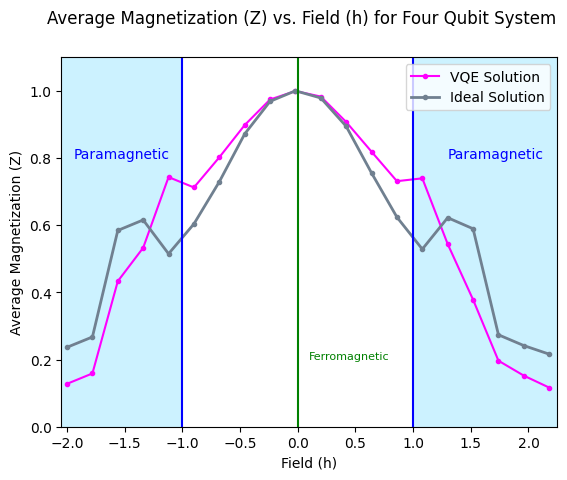

In [ ]:
import scipy, pylab
ax = pylab.subplot(111)
ax.plot(h_values, system_magnetization_z, "fuchsia", marker = '.', linewidth = 1.5)
#ax.plot(h_val, system_magnetization_x, "royalblue", marker = 'o', linewidth = 1.5)
ax.plot(h_values, ideal_z_mag, "slategrey", marker = '.', linewidth = 2)
plt.suptitle("Average Magnetization (Z) vs. Field (h) for Four Qubit System")
#plt.title("(Z-Direction)")

ax.plot([-1,-1],[0,1.1], "blue",linewidth = 1.5)
ax.plot([1,1],[0,1.1], "blue",linewidth = 1.5)
ax.plot([0,0],[0,1.1], "green", linewidth = 1.5)

plt.xlim(-2.05, 2.25)
plt.ylim(0, 1.1)

#plt.axhspan(0, 1, facecolor='b', alpha=0.5)
plt.axvspan(1, 2.25, facecolor='deepskyblue', alpha=0.2)
plt.axvspan(-2.05, -1, facecolor='deepskyblue', alpha=0.2)


ax.text(-1.94,0.8, "Paramagnetic", color='blue', fontsize=10)
ax.text(1.3,0.8, "Paramagnetic", color='blue', fontsize=10)
ax.text(0.1, 0.2, "Ferromagnetic", color = 'green', fontsize = 8)

plt.xlabel("Field (h)")
plt.ylabel("Average Magnetization (Z)")
plt.legend(["VQE Solution", "Ideal Solution"], loc = "upper right")
plt.ticklabel_format(useOffset=False)
ax.figure.show()